In [1]:
import scMPRAforge as scm
from dask.distributed import Client, LocalCluster
from pathlib import Path
import pandas as pd

2025-11-03 11:57:22.578698: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 11:57:23.492836: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")
path=DATA_ROOT/"simulated"
name="shendure_calibrated_sim_with_orthos_20251008"

In [3]:
cluster = LocalCluster(memory_limit='48G')
client = Client(cluster)

In [4]:
simu_obj=scm.de_novo_simulation.load(client,path=path,name=name)

In [5]:
ex_ground_truth=simu_obj.ground_truth

In [6]:
def load_result(root: Path, hypothesis: str, test: str, replicate: int) -> pd.DataFrame:
    """Load a TSV result from the given directory structure."""
    path = root / hypothesis / test / str(replicate)
    if not path.exists():
        raise FileNotFoundError(f"No such file: {path}")
    return pd.read_csv(path, sep='\t')

In [7]:
def merge_in_ground_truth(results,ground_truth):    
        merged=results.merge(ground_truth,
            left_on=["comparison_CRE","comparison_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"comparison_truth"},axis=1)

        #merge in `reference` ground truth
        merged=merged.merge(ground_truth,
            left_on=["reference_CRE","reference_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"reference_truth"},axis=1)

        #ground truth effect size
        merged["gt_effect_size"]=merged["comparison_truth"]/merged["reference_truth"]
        #ground truth null hypothesis that the CREs are the same : true or false?
        merged["gt_null"]=abs(merged["gt_effect_size"]-1)<1e-8

        merged["reject_null"]=merged["bh_p"]<0.05

        #godawful hack
        #merged=merged.dropna(subset=["p_value"])

        return merged

In [8]:
ground_truth=simu_obj.ground_truth

records = []

for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)
            ct = pd.crosstab(ex_merged["gt_null"], ex_merged["reject_null"])
            # Flatten the crosstab into a dict of counts
            for (gt, reject), count in ct.stack().items():
                records.append({
                    "test": test,
                    "hypothesis_set": hypothesis_set,
                    "replicate": replicate,
                    "gt_null": gt,
                    "reject_null": reject,
                    "count": count
                })

df = pd.DataFrame(records)
summary = (df.groupby(["test", "hypothesis_set", "gt_null", "reject_null"])
                ["count"]
                .agg(["mean", "std", "sum", "count"])
                .reset_index())

In [9]:
ex[ex.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p
1246,Col5a1_chr2_2558,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Col5a1_chr2_2558,wald,1.0
1247,Epas1_chr17_10070,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Epas1_chr17_10070,wald,1.0
1248,Gata4_chr14_5714,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Gata4_chr14_5714,wald,1.0
1249,Klf4_chr4_3934,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Klf4_chr4_3934,wald,1.0
1250,Lama1_chr17_7799,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Lama1_chr17_7799,wald,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Sox17_chr1_68,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Sox17_chr1_68,wald,1.0
1448,Lama1_chr17_7791,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Lama1_chr17_7791,wald,1.0
1449,Lamc1_chr1_12183,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Lamc1_chr1_12183,wald,1.0
1450,Cited2_chr10_1239,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Cited2_chr10_1239,wald,1.0


In [10]:
ex_merged

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
0,Col1a2_chr6_77,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.222389,2.215606e-01,1.389442,False,ok,wald,2.839417e-01,0.053783,0.045633,1.178605,False,False
1,Gata4_chr14_5760,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.892192,5.493939e-12,5.537543,False,ok,wald,1.190627e-11,0.210918,0.045633,4.622074,False,True
2,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.817538,1.347899e-04,0.354883,False,ok,wald,2.236742e-04,0.016147,0.045633,0.353838,False,True
3,Sparc_chr11_7195,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.719604,1.822198e-11,4.201281,False,ok,wald,3.896659e-11,0.181964,0.045633,3.987582,False,True
4,Bend5_chr4_8174,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.971483,4.866866e-02,1.674415,False,ok,wald,6.755917e-02,0.064510,0.045633,1.413687,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Sox17_chr1_68,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Sox17_chr1_68,wald,1.000000e+00,0.069617,0.165915,0.419595,False,False
1448,Lama1_chr17_7791,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Lama1_chr17_7791,wald,1.000000e+00,0.058268,0.165915,0.351195,False,False
1449,Lamc1_chr1_12183,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Lamc1_chr1_12183,wald,1.000000e+00,0.015371,0.165915,0.092641,False,False
1450,Cited2_chr10_1239,reference,reference,reference,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Cited2_chr10_1239,wald,1.000000e+00,0.019628,0.165915,0.118300,False,False


In [11]:
records = []
for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        correct_fracs = []
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)

            # since gt_null is always False, "correct" means reject_null == True
            frac_correct = (ex_merged["reject_null"] == True).mean()
            correct_fracs.append(frac_correct)

        records.append({
            "test": test,
            "hypothesis_set": hypothesis_set,
            "mean_fraction_correct": pd.Series(correct_fracs).mean(),
            "std_fraction_correct": pd.Series(correct_fracs).std(),
        })

pd.DataFrame(records)

,test,hypothesis_set,mean_fraction_correct,std_fraction_correct
0,mwu,hs_all_cre,0.850722,0.006786
1,mwu,hs_all_ct,0.857576,0.007328
2,wald,hs_all_cre,0.860514,0.007052
3,wald,hs_all_ct,0.734986,0.048188


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_p_vs_effect(hypothesis_set, test, replicate):
    ex = load_result(root=path/name/"results",
                     hypothesis=hypothesis_set,
                     test=test,
                     replicate=replicate)
    df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

    # compute color by log10(max of comparison_truth and reference_truth)
    df["log_max_activity"] = np.log10(np.maximum(df["comparison_truth"], df["reference_truth"]).clip(lower=1e-12))

    # use a reversed warm colormap (small = red/yellow, large = blue)
    sns.scatterplot(data=df, x="gt_effect_size", y="p_value", hue="log_max_activity",
                    palette="inferno_r", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-2, 1e4)
    plt.ylim(1e1, 1e-300)

    plt.xlabel("Ground Truth Effect Size (log scale)")
    plt.ylabel("p-value (log scale)")
    plt.legend(title="log10(Max Activity)")
    plt.title(f"p-value vs Ground Truth Effect Size\n(test={test}, hypothesis_set={hypothesis_set}, replicate={replicate})")
    plt.tight_layout()
    plt.show()


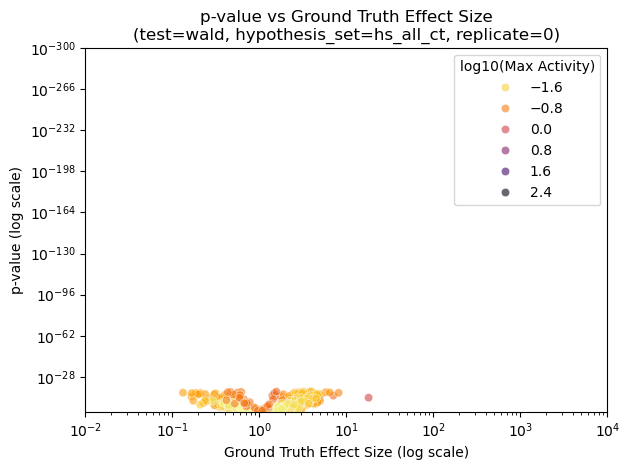

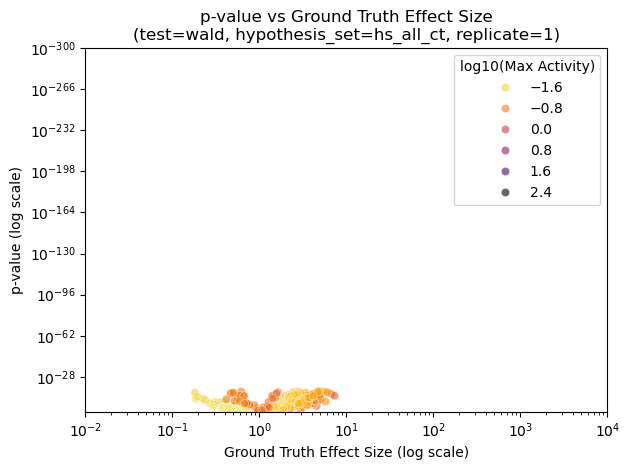

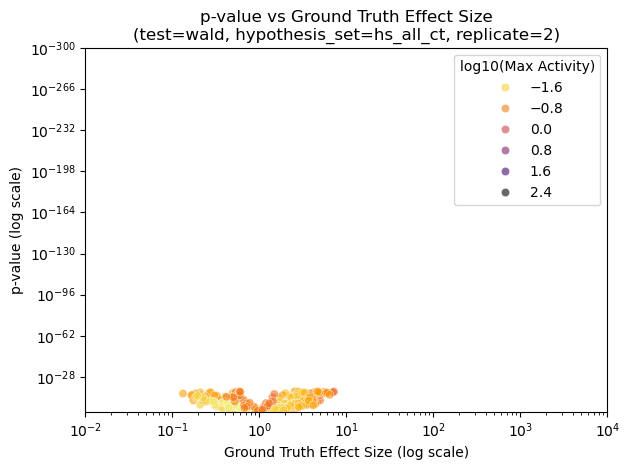

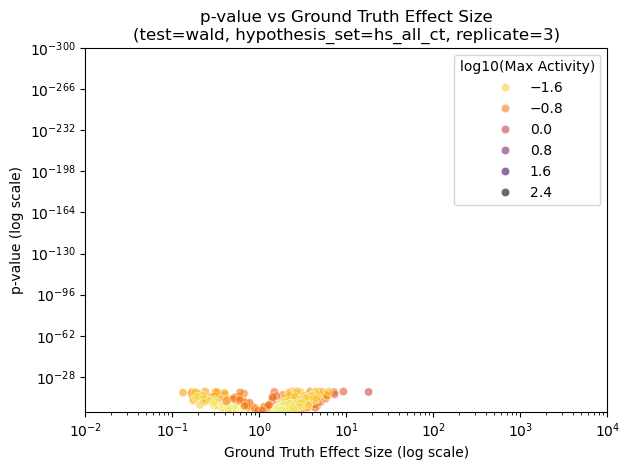

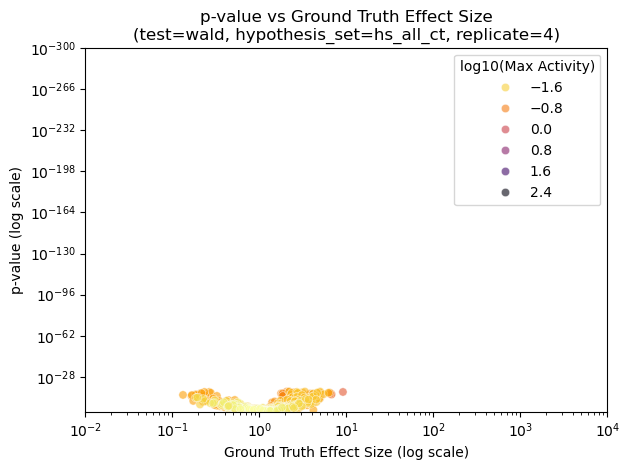

In [31]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate=replicate)

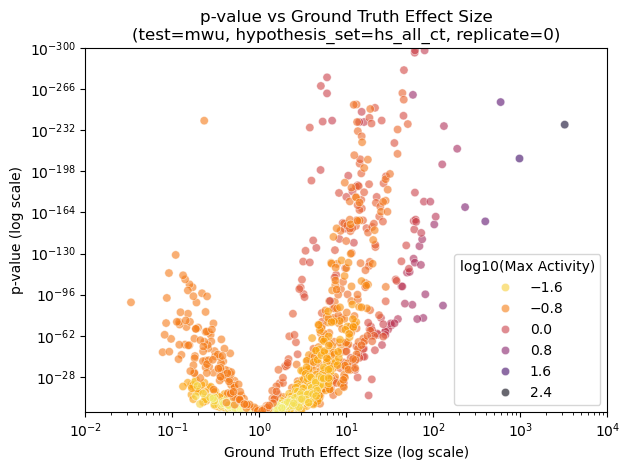

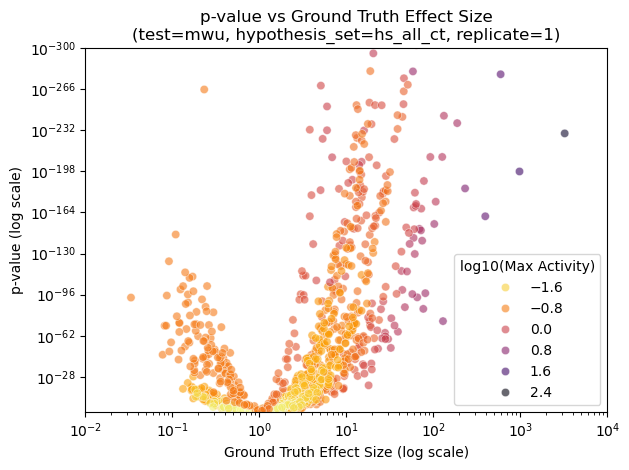

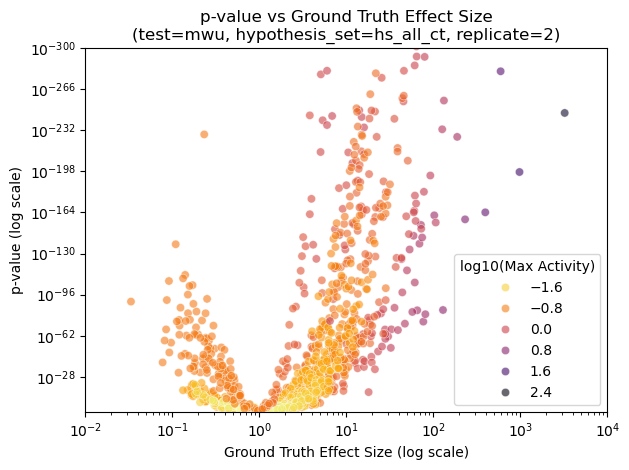

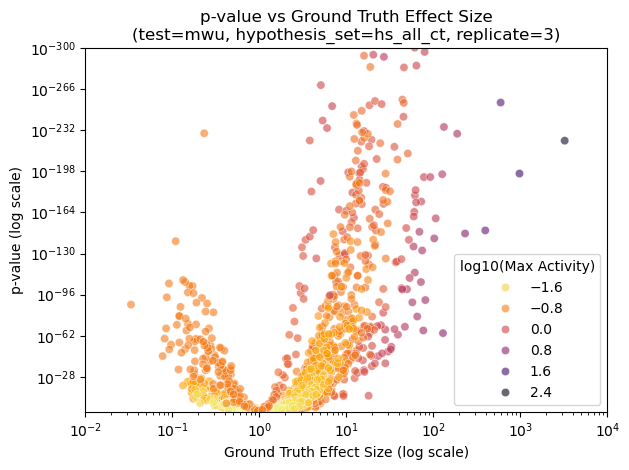

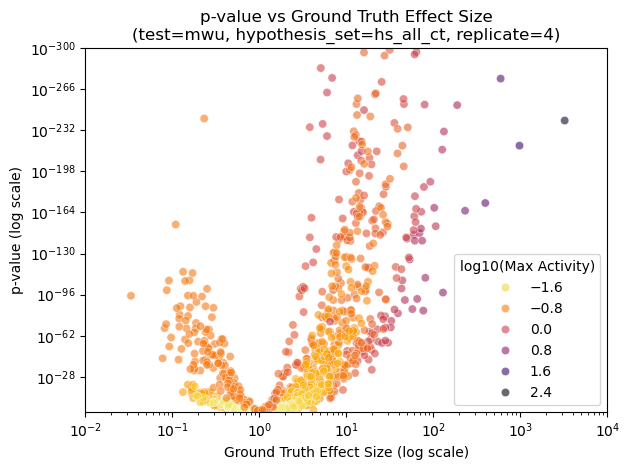

In [13]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="mwu",replicate=replicate)

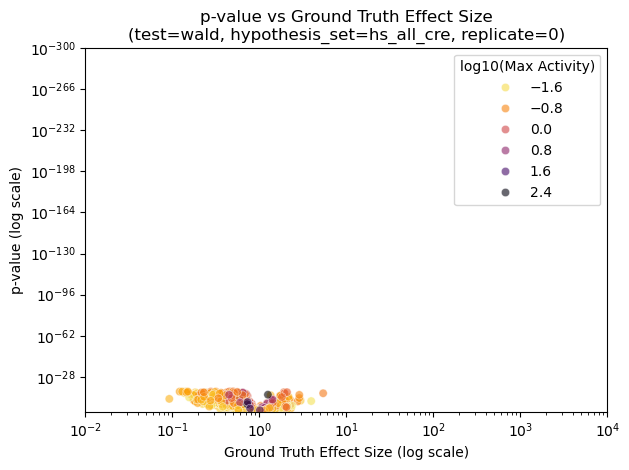

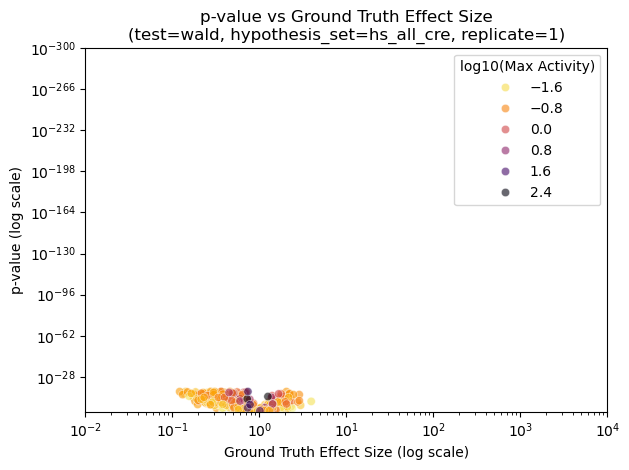

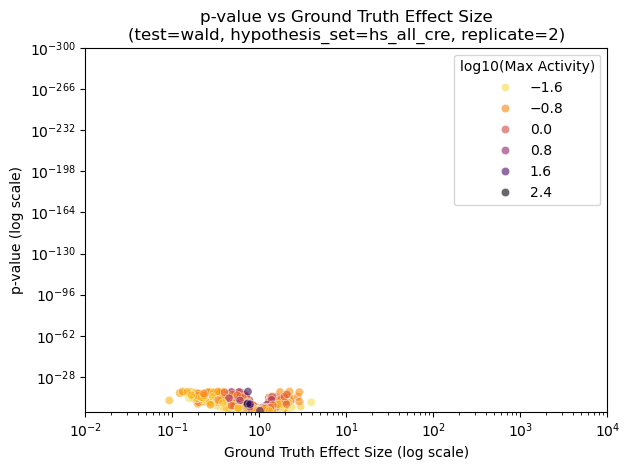

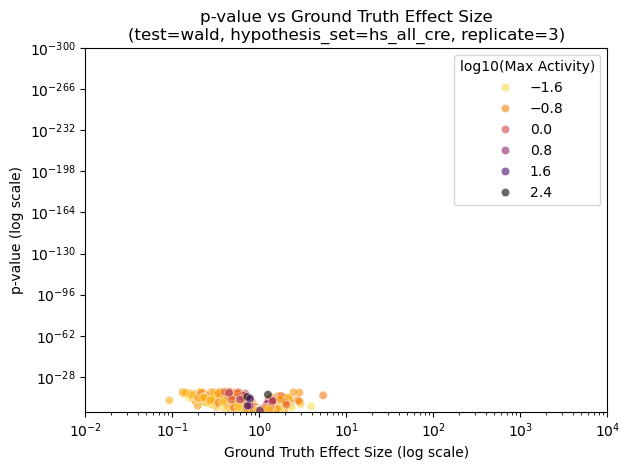

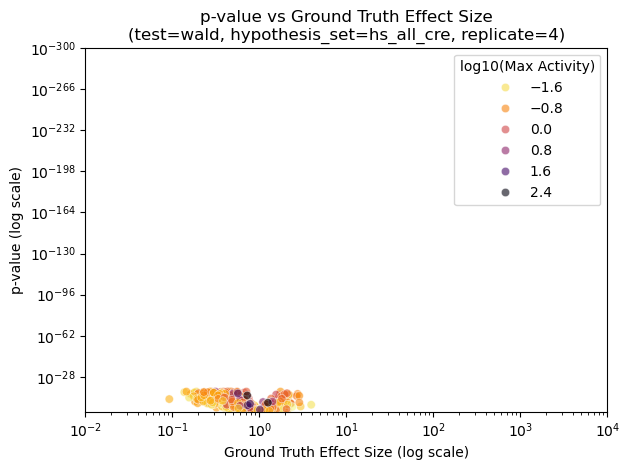

In [14]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="wald",replicate=replicate)

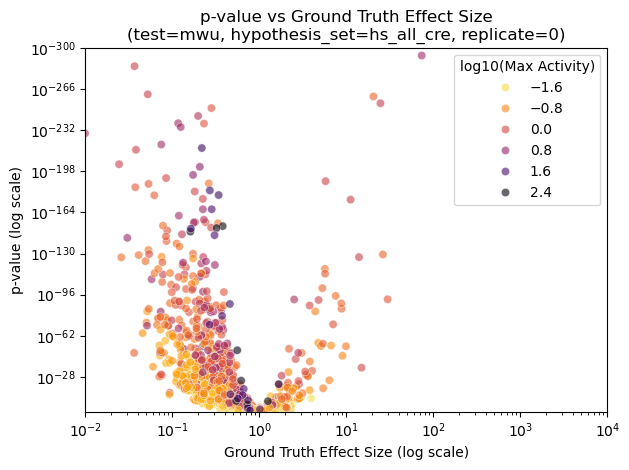

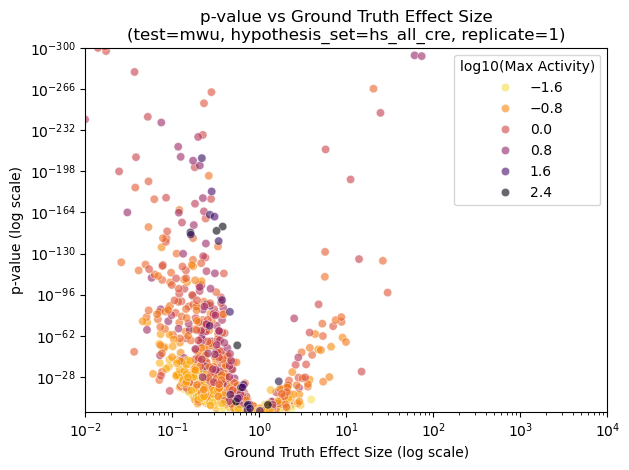

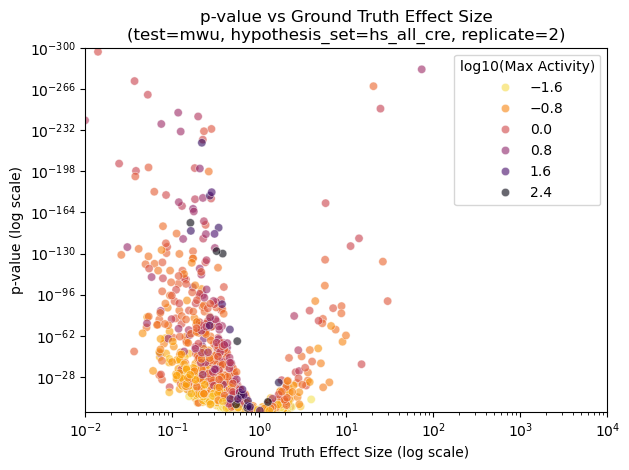

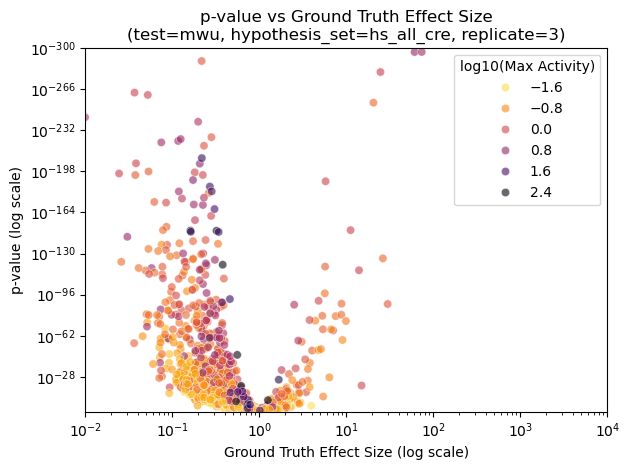

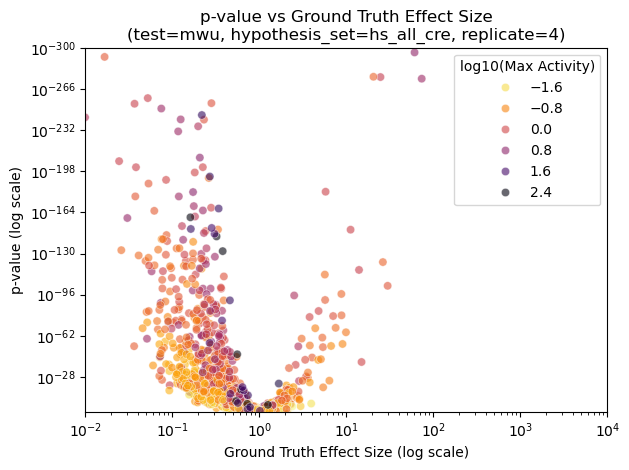

In [15]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="mwu",replicate=replicate)

In [16]:
ex = load_result(root=path/name/"results",
                     hypothesis="hs_all_ct",
                     test="wald",
                     replicate=0)
df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

In [17]:
df[df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
676,Bend5_chr4_8174,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Bend5_chr4_8174,wald,1.0,0.010820,0.01935,0.559138,False,False
677,Bend5_chr4_8192,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Bend5_chr4_8192,wald,1.0,0.003617,0.01935,0.186938,False,False
678,Cited2_chr10_1248,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Cited2_chr10_1248,wald,1.0,0.008955,0.01935,0.462779,False,False
679,Foxa2_chr2_13812,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Foxa2_chr2_13812,wald,1.0,0.010508,0.01935,0.543034,False,False
680,Foxa2_chr2_13841,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Foxa2_chr2_13841,wald,1.0,0.042710,0.01935,2.207171,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,Col1a1_chr11_15316,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Col1a1_chr11_15316,wald,1.0,0.043459,0.01935,2.245884,False,False
848,Sox4_chr13_2055,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Sox4_chr13_2055,wald,1.0,0.149886,0.01935,7.745899,False,False
849,Tgfbi_chr13_5711,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Tgfbi_chr13_5711,wald,1.0,0.040802,0.01935,2.108575,False,False
850,Igfbp4_chr11_16716,Mesoderm,reference,Mesoderm,emvar_screen,NaN,NaN,NaN,False,ok; non-finite se for Igfbp4_chr11_16716,wald,1.0,0.032734,0.01935,1.691637,False,False


In [18]:
df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
0,Col1a2_chr6_77,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.940575,5.230982e-02,1.655923,False,ok,wald,6.812005e-02,0.053783,0.045633,1.178605,False,False
1,Gata4_chr14_5760,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.190294,6.005227e-10,4.785777,False,ok,wald,1.084526e-09,0.210918,0.045633,4.622074,False,True
2,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.415865,6.357967e-04,0.414482,False,ok,wald,9.250268e-04,0.016147,0.045633,0.353838,False,True
3,Sparc_chr11_7195,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,8.069774,6.661338e-16,5.366587,False,ok,wald,1.375855e-15,0.181964,0.045633,3.987582,False,True
4,Bend5_chr4_8174,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.537423,1.241898e-01,1.509636,False,ok,wald,1.568031e-01,0.064510,0.045633,1.413687,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Sox17_chr1_68,reference,reference,reference,emvar_screen,-6.045817,1.486551e-09,0.465571,False,ok,wald,2.671376e-09,0.069617,0.165915,0.419595,False,True
1448,Lama1_chr17_7791,reference,reference,reference,emvar_screen,-11.060169,0.000000e+00,0.313662,False,ok,wald,0.000000e+00,0.058268,0.165915,0.351195,False,True
1449,Lamc1_chr1_12183,reference,reference,reference,emvar_screen,-12.844761,0.000000e+00,0.091737,False,ok,wald,0.000000e+00,0.015371,0.165915,0.092641,False,True
1450,Cited2_chr10_1239,reference,reference,reference,emvar_screen,-11.390037,0.000000e+00,0.073233,False,ok,wald,0.000000e+00,0.019628,0.165915,0.118300,False,True


In [20]:
# What failed and how many
print(df["wald_debug"].value_counts(dropna=False).head(20))


wald_debug
ok                                          1276
ok; non-finite se for Cited2_chr10_1254        1
ok; non-finite se for Cited2_chr10_1267        1
ok; non-finite se for Foxa2_chr2_13808         1
ok; non-finite se for Igfbp4_chr11_16738       1
ok; non-finite se for Igfbp4_chr11_16740       1
ok; non-finite se for Tubb2b_chr13_2578        1
ok; non-finite se for Gata4_chr14_5710         1
ok; non-finite se for Igfbp4_chr11_16743       1
ok; non-finite se for Klf4_chr4_3934           1
ok; non-finite se for Klf4_chr4_3948           1
ok; non-finite se for Sparc_chr11_7211         1
ok; non-finite se for Foxa2_chr2_13858         1
ok; non-finite se for Gata4_chr14_5677         1
ok; non-finite se for Igfbp4_chr11_16728       1
ok; non-finite se for Lamb1_chr12_2288         1
ok; non-finite se for Txndc12_chr4_7951        1
ok; non-finite se for Lamb1_chr12_2186         1
ok; non-finite se for Bend5_chr4_8172          1
ok; non-finite se for Col5a1_chr2_2571         1
Name: cou

In [21]:

# Which CT/CRE pairs are most affected
print(df[df["wald_debug"]!="ok"].groupby(
      ["comparison_cell_type","comparison_CRE","wald_debug"]
).size().sort_values(ascending=False).head(20))


comparison_cell_type  comparison_CRE      wald_debug                              
Mesoderm              Tubb2b_chr13_2572   ok; non-finite se for Tubb2b_chr13_2572     1
                      Tubb2b_chr13_2576   ok; non-finite se for Tubb2b_chr13_2576     1
                      Tubb2b_chr13_2577   ok; non-finite se for Tubb2b_chr13_2577     1
                      Tubb2b_chr13_2578   ok; non-finite se for Tubb2b_chr13_2578     1
                      Tubb2b_chr13_2580   ok; non-finite se for Tubb2b_chr13_2580     1
                      Tubb2b_chr13_2583   ok; non-finite se for Tubb2b_chr13_2583     1
                      Tubb2b_chr13_2590   ok; non-finite se for Tubb2b_chr13_2590     1
                      Txndc12_chr4_7951   ok; non-finite se for Txndc12_chr4_7951     1
                      Btg1_chr10_9588     ok; non-finite se for Btg1_chr10_9588       1
                      Btg1_chr10_9593     ok; non-finite se for Btg1_chr10_9593       1
                      Btg1_chr10_9612

In [22]:

# Are failures tied to extreme BH or beta ~ 0?
df_bad = df[df["wald_debug"]!="ok"]
df_good = df[df["wald_debug"]=="ok"]
print(df_bad["p_value"].describe(), df_good["p_value"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: p_value, dtype: float64 count    1276.000000
mean        0.049457
std         0.155951
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000122
max         0.985844
Name: p_value, dtype: float64


In [26]:
df_bad = df.loc[df["wald_debug"]!="ok"]
fail_by_ct = (
    df_bad.groupby("comparison_cell_type")
          .size()
          .sort_values(ascending=False)
)
print(fail_by_ct)

comparison_cell_type
Mesoderm    176
dtype: int64


In [29]:
df.groupby("comparison_cell_type").size().sort_values(ascending=False)


comparison_cell_type
reference                  206
EpiblastPrimitiveStreak    184
ExEndodermParietal         177
Mesoderm                   176
NeuroectodermBrain         172
ExEndodermVisceral         147
SurfaceEctoderm            138
Haematoendothelial          90
NeuroectodermRostral        84
Cardiomyocytes              78
dtype: int64

In [30]:
df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
0,Col1a2_chr6_77,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.940575,5.230982e-02,1.655923,False,ok,wald,6.812005e-02,0.053783,0.045633,1.178605,False,False
1,Gata4_chr14_5760,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.190294,6.005227e-10,4.785777,False,ok,wald,1.084526e-09,0.210918,0.045633,4.622074,False,True
2,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.415865,6.357967e-04,0.414482,False,ok,wald,9.250268e-04,0.016147,0.045633,0.353838,False,True
3,Sparc_chr11_7195,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,8.069774,6.661338e-16,5.366587,False,ok,wald,1.375855e-15,0.181964,0.045633,3.987582,False,True
4,Bend5_chr4_8174,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.537423,1.241898e-01,1.509636,False,ok,wald,1.568031e-01,0.064510,0.045633,1.413687,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Sox17_chr1_68,reference,reference,reference,emvar_screen,-6.045817,1.486551e-09,0.465571,False,ok,wald,2.671376e-09,0.069617,0.165915,0.419595,False,True
1448,Lama1_chr17_7791,reference,reference,reference,emvar_screen,-11.060169,0.000000e+00,0.313662,False,ok,wald,0.000000e+00,0.058268,0.165915,0.351195,False,True
1449,Lamc1_chr1_12183,reference,reference,reference,emvar_screen,-12.844761,0.000000e+00,0.091737,False,ok,wald,0.000000e+00,0.015371,0.165915,0.092641,False,True
1450,Cited2_chr10_1239,reference,reference,reference,emvar_screen,-11.390037,0.000000e+00,0.073233,False,ok,wald,0.000000e+00,0.019628,0.165915,0.118300,False,True


In [32]:
client.close()
cluster.close()